In [10]:
# ==================== IMPORTS ====================
import pandas as pd 
import kagglehub as kh
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# ==================== DOWNLOAD & LOAD DATA ====================
# Download dataset from KaggleHub
path = kh.dataset_download("shayanfazeli/heartbeat")

def load_data(path):
    mitbih_train = pd.read_csv(os.path.join(path, "mitbih_train.csv"), header=None)
    mitbih_test = pd.read_csv(os.path.join(path, "mitbih_test.csv"), header=None)
    ptbdb_normal = pd.read_csv(os.path.join(path, "ptbdb_normal.csv"), header=None)
    ptbdb_abnormal = pd.read_csv(os.path.join(path, "ptbdb_abnormal.csv"), header=None)
    return mitbih_train, mitbih_test, ptbdb_normal, ptbdb_abnormal

mitbih_train, mitbih_test, ptbdb_normal, ptbdb_abnormal = load_data(path)

# ==================== ASSIGN LABELS FOR PTBDB ====================
def replace_label_column(data, label):
    data.iloc[:, -1] = label
    return data

ptbdb_normal = replace_label_column(ptbdb_normal, 6)  # normal
ptbdb_abnormal = replace_label_column(ptbdb_abnormal, 7)  # abnormal

ptbdb_all = pd.concat([ptbdb_normal, ptbdb_abnormal], ignore_index=True)

# ==================== SPLIT PTBDB ONLY ====================
X_ptbdb_train, X_ptbdb_test, y_ptbdb_train, y_ptbdb_test = train_test_split(
    ptbdb_all.iloc[:, :-1], ptbdb_all.iloc[:, -1], test_size=0.2, random_state=42
)

# ==================== COMBINE WITH MITBIH ====================
X_train_df = pd.concat([X_ptbdb_train, mitbih_train.iloc[:, :-1]], ignore_index=True)
y_train = pd.concat([y_ptbdb_train, mitbih_train.iloc[:, -1]], ignore_index=True)

X_test_df = pd.concat([X_ptbdb_test, mitbih_test.iloc[:, :-1]], ignore_index=True)
y_test = pd.concat([y_ptbdb_test, mitbih_test.iloc[:, -1]], ignore_index=True)

# ==================== LABEL REMAPPING ====================
# Merge class 6 into 0 ("Normal"), rename 7 to 5 ("Abnormal")
y_train = y_train.astype(int).replace({6: 0, 7: 5}).reset_index(drop=True)
y_test = y_test.astype(int).replace({6: 0, 7: 5}).reset_index(drop=True)

# ==================== DROP LOW-INFORMATION COLUMNS ====================
def drop_almost_zero_columns(X, threshold=0.8):
    zero_fraction = (X == 0).sum() / len(X)
    drop_cols = zero_fraction[zero_fraction >= threshold].index
    return X.drop(columns=drop_cols)

X_train_df = drop_almost_zero_columns(X_train_df)
X_test_df = drop_almost_zero_columns(X_test_df)

# ==================== CONVERT TO NUMPY ====================
X_train = X_train_df.values
X_test = X_test_df.values
y_train = y_train.values
y_test = y_test.values

# ==================== SPLIT TRAIN -> TRAIN + VALIDATION ====================
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# ==================== NORMALIZATION ====================
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==================== RESHAPE FOR CNN INPUT ====================
X_train_final = X_train_final.reshape((X_train_final.shape[0], X_train_final.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ==================== ONE-HOT ENCODE LABELS ====================
# Infer number of classes from all combined y
all_labels = np.concatenate([y_train, y_test])
unique_classes = np.unique(all_labels)
num_classes = len(unique_classes)

y_train_cat = to_categorical(y_train_final, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# ==================== CLASS WEIGHTS (Manually Defined) ====================
class_weights = {
    0: 1.0,   # Normal
    1: 4.0,   # Supraventricular
    2: 1.5,   # Ventricular
    3: 5.0,   # Fusion
    4: 1.0,   # Unknown
    5: 1.2    # Abnormal
}

# ==================== HUMAN READABLE CONDITIONS (Optional Mapping) ====================
conditions = {
    0: "Normal (N)",
    1: "Supraventricular premature (S)",
    2: "Premature ventricular contraction (V)",
    3: "Fusion of ventricular and normal beat (F)",
    4: "Unclassifiable beat (Q)",
    5: "Abnormal (A)"
}


In [12]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, MaxPool1D, BatchNormalization,
                                     Dense, Dropout, GlobalAveragePooling1D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=1.0, from_logits=False,
                 reduction='sum_over_batch_size', name='focal_loss'):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma
        self.alpha = tf.constant(alpha, dtype=tf.float32)
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, y_pred.dtype)

        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred, axis=-1)

        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)

        # Fix: shape of alpha to match p_t
        alpha_t = tf.reduce_sum(y_true * self.alpha, axis=-1)

        focal = tf.pow(1.0 - p_t, self.gamma)
        loss = -alpha_t * focal * tf.math.log(tf.clip_by_value(p_t, 1e-7, 1.0))

        return loss


In [ ]:
# import tensorflow as tf
# from tensorflow.keras.layers import (Input, Conv1D, MaxPool1D, BatchNormalization,
#                                      Dense, Dropout, GlobalAveragePooling1D)
# from tensorflow.keras.models import Model
# from tensorflow.keras.optimizers import Adam
# import keras_tuner as kt
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns
# import pandas as pd

# # Custom Focal Loss
# class FocalLoss(tf.keras.losses.Loss):
#     def __init__(self, gamma=2.0, alpha=1.0, from_logits=False,
#                  reduction='sum_over_batch_size', name='focal_loss'):
#         super().__init__(reduction=reduction, name=name)
#         self.gamma = gamma
#         self.alpha = tf.constant(alpha, dtype=tf.float32)
#         self.from_logits = from_logits

#     def call(self, y_true, y_pred):
#         y_true = tf.cast(y_true, y_pred.dtype)
#         if self.from_logits:
#             y_pred = tf.nn.softmax(y_pred, axis=-1)
#         p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
#         alpha_t = self.alpha if self.alpha.shape.rank == 1 else 1.0
#         focal = tf.pow(1.0 - p_t, self.gamma)
#         loss = -alpha_t * focal * tf.math.log(tf.clip_by_value(p_t, 1e-7, 1.0))
#         return loss


In [13]:
SEQ_LEN, N_CHANNELS = X_train_final.shape[1:]  # (length, channels)
NUM_CLASSES = y_train_cat.shape[1]

alpha_vec = [class_weights[i] for i in range(len(class_weights))]

def build_model(hp):
    filters = hp.Int("filters", 32, 128, step=32)
    dense_units = hp.Int("dense_units", 64, 256, step=64)
    dropout = hp.Float("dropout", 0.1, 0.5, step=0.1)
    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")
    gamma = hp.Float("gamma", 1.5, 3.0, step=0.5)

    inp = Input(shape=(SEQ_LEN, N_CHANNELS))
    x = Conv1D(filters, 5, activation='relu', padding='same')(inp)
    x = MaxPool1D(2)(x)
    x = BatchNormalization()(x)

    x = Conv1D(filters * 2, 3, activation='relu', padding='same')(x)
    x = MaxPool1D(2)(x)
    x = BatchNormalization()(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(dropout)(x)
    out = Dense(NUM_CLASSES)(x)

    model = Model(inputs=inp, outputs=out)

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=FocalLoss(gamma=gamma, alpha=alpha_vec, from_logits=True),
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='prec'),
            tf.keras.metrics.Recall(name='rec'),
            tf.keras.metrics.AUC(name='pr_auc', curve='PR')
        ]
    )
    return model


In [14]:
tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective("val_pr_auc", direction="max"),
    max_epochs=20,
    factor=3,
    directory="tuner_logs",
    project_name="cnn_focal_tuning"
)

tuner.search(
    X_train_final, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc", factor=0.5, patience=2)
    ],
    verbose=2
)


Trial 26 Complete [00h 00m 34s]
val_pr_auc: 0.7559579014778137

Best val_pr_auc So Far: 0.7999802827835083
Total elapsed time: 00h 32m 16s


In [16]:
top_hps = tuner.get_best_hyperparameters(3)
top_models = []
top_histories = []

for i, hp in enumerate(top_hps):
    print(f"\n🔧 Retraining Top-{i+1} model with hyperparameters: {hp.values}")
    model = build_model(hp)

    history = model.fit(
        X_train_final, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=20,
        batch_size=256,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=5, restore_best_weights=True)
        ],
        verbose=0
    )
    top_models.append(model)
    top_histories.append(history)



🔧 Retraining Top-1 model with hyperparameters: {'filters': 128, 'dense_units': 64, 'dropout': 0.4, 'lr': 0.0015359876270177853, 'gamma': 1.5, 'tuner/epochs': 7, 'tuner/initial_epoch': 0, 'tuner/bracket': 1, 'tuner/round': 0}

🔧 Retraining Top-2 model with hyperparameters: {'filters': 64, 'dense_units': 256, 'dropout': 0.4, 'lr': 0.0019017054353517517, 'gamma': 1.5, 'tuner/epochs': 3, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}

🔧 Retraining Top-3 model with hyperparameters: {'filters': 32, 'dense_units': 256, 'dropout': 0.30000000000000004, 'lr': 0.0001323743940619104, 'gamma': 1.5, 'tuner/epochs': 20, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}


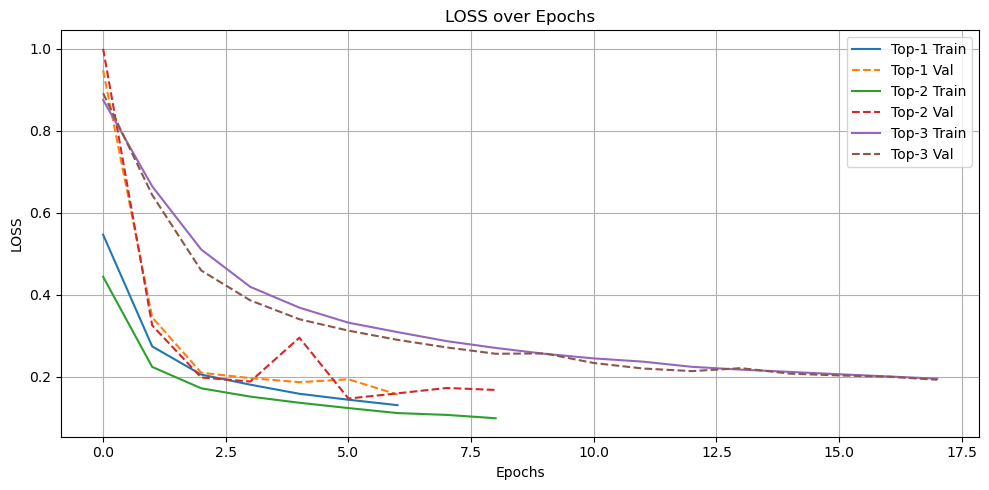

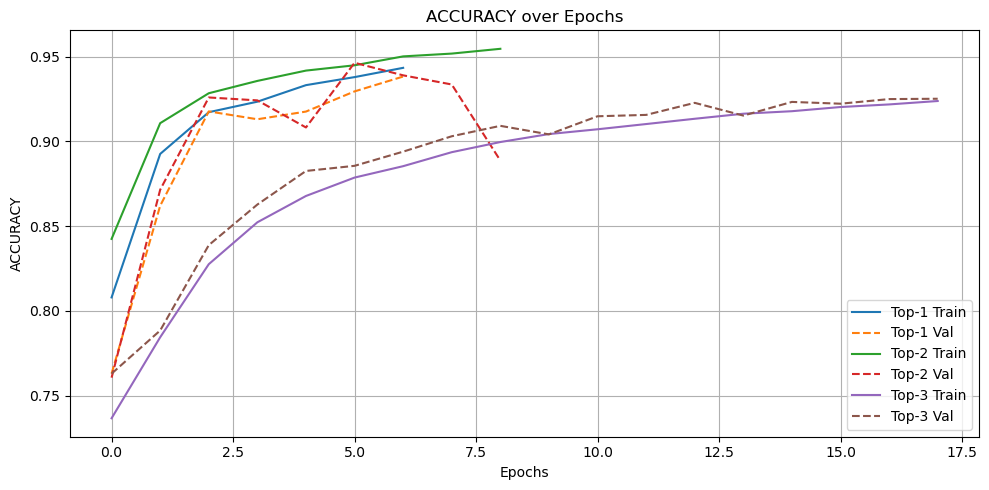

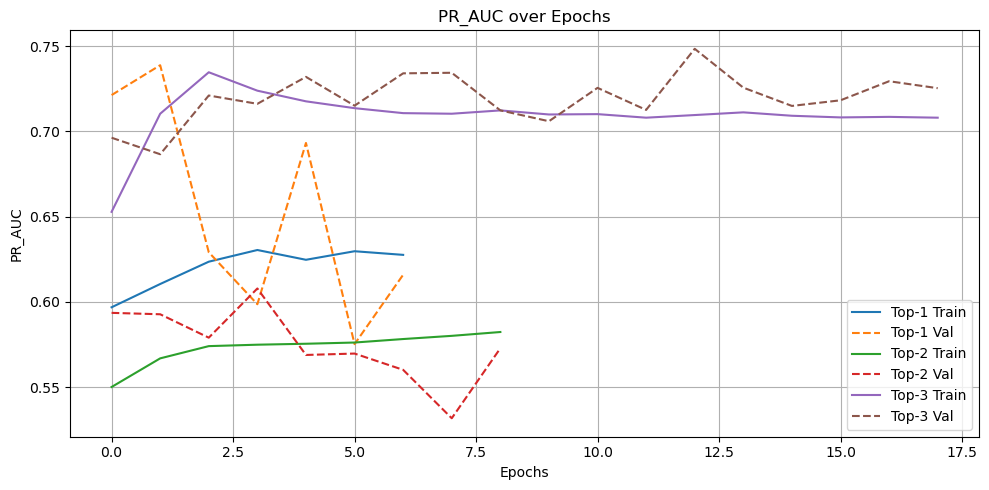

In [17]:
metrics = ['loss', 'accuracy', 'pr_auc']

for metric in metrics:
    plt.figure(figsize=(10, 5))
    for i, history in enumerate(top_histories):
        plt.plot(history.history[metric], label=f"Top-{i+1} Train")
        plt.plot(history.history[f"val_{metric}"], linestyle='--', label=f"Top-{i+1} Val")
    plt.title(f"{metric.upper()} over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [18]:
best_model = top_models[0]
test_metrics = best_model.evaluate(X_test, y_test_cat, batch_size=256)
print("\nTest Performance:")
print(dict(zip(best_model.metrics_names, test_metrics)))

97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8065 - loss: 0.2941 - pr_auc: 0.6980 - prec: 0.6206 - rec: 0.9485

Test Performance:
{'loss': 0.35052794218063354, 'compile_metrics': 0.8607023358345032}


776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


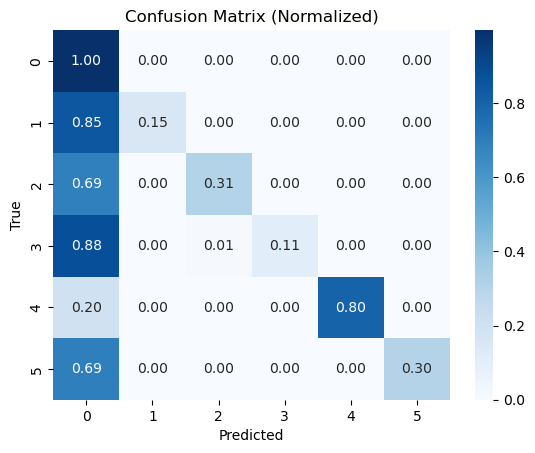


Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     18952
           1       0.87      0.15      0.26       556
           2       0.96      0.31      0.47      1448
           3       1.00      0.11      0.20       162
           4       0.99      0.80      0.89      1608
           5       0.94      0.30      0.46      2077

    accuracy                           0.86     24803
   macro avg       0.93      0.45      0.53     24803
weighted avg       0.87      0.86      0.83     24803



In [19]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred, normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred))
